In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as sig
import tensorflow as tf
import pywt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split ,StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalAveragePooling1D, LSTM
from tensorflow.keras.models import Sequential
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [2]:
# Load your test datasets
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')
X_train = np.load('TEST1/X_train.npy')
y_train = np.load('TEST1/y_train.npy')

In [3]:
# Encode the labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

C:\Users\user\AppData\Local\Temp\ipykernel_15968\3860742871.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


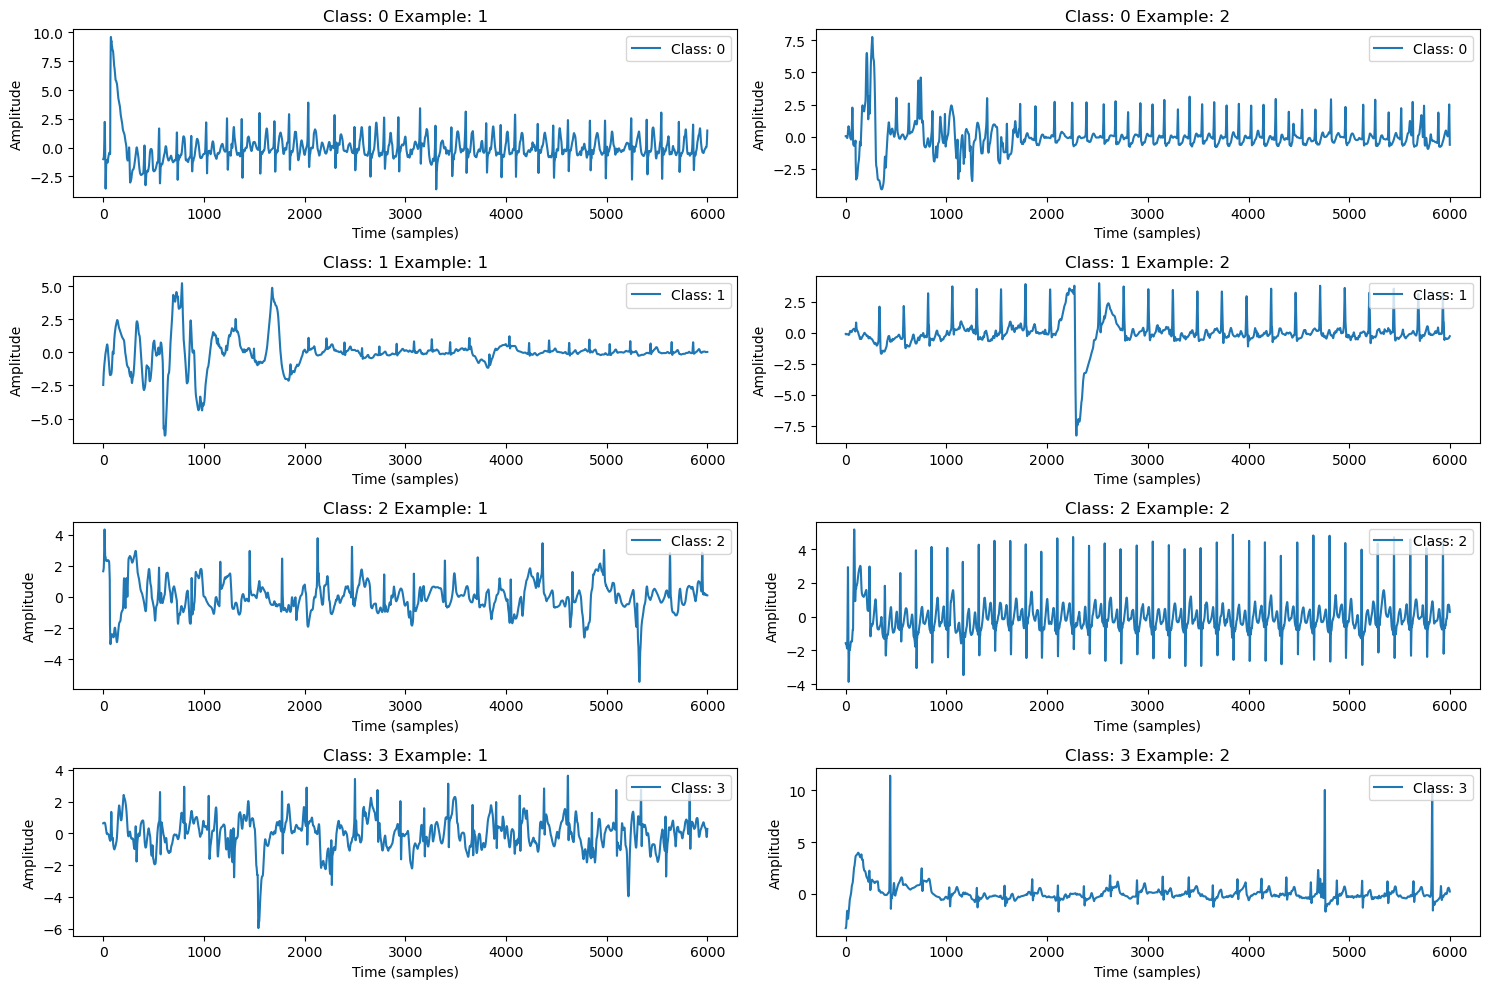

In [4]:
def plot_signal_per_class(X, y, label_encoder, num_examples=1):
    # Get unique classes
    unique_classes = np.unique(y)
    # Reverse mapping of labels to class names
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    plt.figure(figsize=(15, 10))
    for i, class_label in enumerate(unique_classes):
        indices = np.where(y == class_label)[0]
        for j in range(min(num_examples, len(indices))):
            index = indices[j]
            plt.subplot(len(unique_classes), num_examples, i * num_examples + j + 1)
            plt.plot(X[index].squeeze(), label=f'Class: {reverse_label_mapping[class_label]}')
            plt.legend(loc='upper right')
            plt.title(f'Class: {reverse_label_mapping[class_label]} Example: {j+1}')
            plt.xlabel('Time (samples)')
            plt.ylabel('Amplitude')
            plt.tight_layout()

    plt.show()

# Call the function to plot a signal from each class
plot_signal_per_class(X_train, y_train, label_encoder, num_examples=2)

In [5]:
# Perform stratified k-fold cross-validation, build and evaluate the model on each fold
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

train_accuracies, val_accuracies, test_accuracies = [], [], []

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {fold + 1}/{num_folds}")
    X_train_fold, X_val = X_train[train_index], X_train[val_index]
    y_train_fold, y_val = y_train[train_index], y_train[val_index]

    # Build the model
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=8, kernel_size=5, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=16, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=32, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=128, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=256, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=512, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
    )

    train_accuracy = model.evaluate(X_train, y_train, verbose=0)[1]
    val_accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]

    print(f"Training Accuracy: {train_accuracy}, Validation Accuracy: {val_accuracy}, Test Accuracy: {test_accuracy}")

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)

Fold 1/10
Epoch 1/50


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.5608 - loss: 1.0180 - val_accuracy: 0.6195 - val_loss: 0.8527
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.6245 - loss: 0.8308 - val_accuracy: 0.6588 - val_loss: 0.7360
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.6864 - loss: 0.7290 - val_accuracy: 0.6981 - val_loss: 0.6720
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.7153 - loss: 0.6691 - val_accuracy: 0.7396 - val_loss: 0.6458
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.7517 - loss: 0.6104 - val_accuracy: 0.7845 - val_loss: 0.5514
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.7789 - loss: 0.5652 - val_accuracy: 0.8159 - val_loss: 0.5211
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.8074 - loss: 0.5251 - val_accuracy: 0.8249 - val_loss: 0.5098
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.8041 - loss: 0.5188 - val

140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9936 - loss: 0.0218 - val_accuracy: 0.9910 - val_loss: 0.0262
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9926 - loss: 0.0192 - val_accuracy: 0.9764 - val_loss: 0.0719
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9883 - loss: 0.0350 - val_accuracy: 0.9966 - val_loss: 0.0072
Training Accuracy: 0.9974169135093689, Validation Accuracy: 0.996632993221283, Test Accuracy: 0.9782718420028687
Fold 3/10
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.5542 - loss: 1.0190 - val_accuracy: 0.6139 - val_loss: 0.8367
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.6203 - loss: 0.8418 - val_accuracy: 0.6543 - val_loss: 0.7513
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.6638 - loss: 0.7512 - val_accuracy: 0.7172 - val_loss: 0.6575
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.7246 - loss: 0.6659 - val_accur

140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.9927 - loss: 0.0232 - val_accuracy: 0.9776 - val_loss: 0.0748
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9847 - loss: 0.0502 - val_accuracy: 0.9978 - val_loss: 0.0107
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9904 - loss: 0.0338 - val_accuracy: 0.9753 - val_loss: 0.0601
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9806 - loss: 0.0546 - val_accuracy: 0.9966 - val_loss: 0.0073
Epoch 48/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9948 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9938 - loss: 0.0210 - val_accuracy: 0.9944 - val_loss: 0.0236
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9871 - loss: 0.0367 - val_accuracy: 0.9989 - val_loss: 0.0050
Training Accuracy: 0.9985399842262268, Validation Accuracy: 0.9988776445388794, Test Acc

140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9883 - loss: 0.0305 - val_accuracy: 0.9899 - val_loss: 0.0203
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9657 - loss: 0.1099 - val_accuracy: 0.9944 - val_loss: 0.0140
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9909 - loss: 0.0256 - val_accuracy: 0.9955 - val_loss: 0.0114
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9944 - loss: 0.0204 - val_accuracy: 0.9944 - val_loss: 0.0179
Epoch 44/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9966 - val_loss: 0.0154
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9875 - loss: 0.0461 - val_accuracy: 0.9978 - val_loss: 0.0095
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9794 - loss: 0.0675 - val_accuracy: 0.9978 - val_loss: 0.0069
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9910 - loss: 0.024

140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9800 - loss: 0.0696 - val_accuracy: 0.9854 - val_loss: 0.0375
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9912 - loss: 0.0344 - val_accuracy: 0.9921 - val_loss: 0.0335
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9845 - loss: 0.0453 - val_accuracy: 0.9910 - val_loss: 0.0264
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9887 - loss: 0.0408 - val_accuracy: 0.9865 - val_loss: 0.0336
Epoch 40/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9846 - loss: 0.0546 - val_accuracy: 0.9899 - val_loss: 0.0212
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9924 - loss: 0.0242 - val_accuracy: 0.9978 - val_loss: 0.0130
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9854 - val_loss: 0.0382
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9919 - loss: 0.026

140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9682 - loss: 0.0936 - val_accuracy: 0.9764 - val_loss: 0.0612
Epoch 33/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9639 - loss: 0.1073 - val_accuracy: 0.9843 - val_loss: 0.0403
Epoch 34/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9786 - loss: 0.0664 - val_accuracy: 0.9876 - val_loss: 0.0526
Epoch 35/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.9805 - loss: 0.0600 - val_accuracy: 0.9933 - val_loss: 0.0237
Epoch 36/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9862 - loss: 0.0435 - val_accuracy: 0.9854 - val_loss: 0.0409
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9825 - loss: 0.0486 - val_accuracy: 0.9955 - val_loss: 0.0185
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9845 - loss: 0.0487 - val_accuracy: 0.9831 - val_loss: 0.0533
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9820 - loss: 0.054

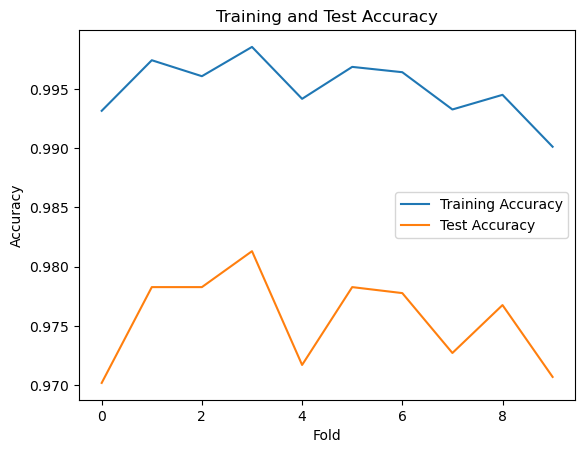

In [6]:
# Plot the training and test accuracies for each fold
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.show()

In [7]:
# Calculate the mean accuracies for training and test sets
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)


print(f"Mean Test Accuracy: {mean_test_accuracy} ")
print(f"Mean Training Accuracy: {mean_train_accuracy} ")

Mean Test Accuracy: 0.9755937278270721 
Mean Training Accuracy: 0.9950471758842468 


In [8]:
# Predict labels for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert class labels to strings for classification_report
target_names = [str(i) for i in label_encoder.classes_]

# Generate classification report
report = classification_report(y_test, y_pred_classes, target_names=target_names)

# Print classification report
print(report)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       185
           1       0.98      0.99      0.98      1137
           2       0.96      0.95      0.96       627
           3       0.97      0.93      0.95        30

    accuracy                           0.97      1979
   macro avg       0.97      0.95      0.96      1979
weighted avg       0.97      0.97      0.97      1979



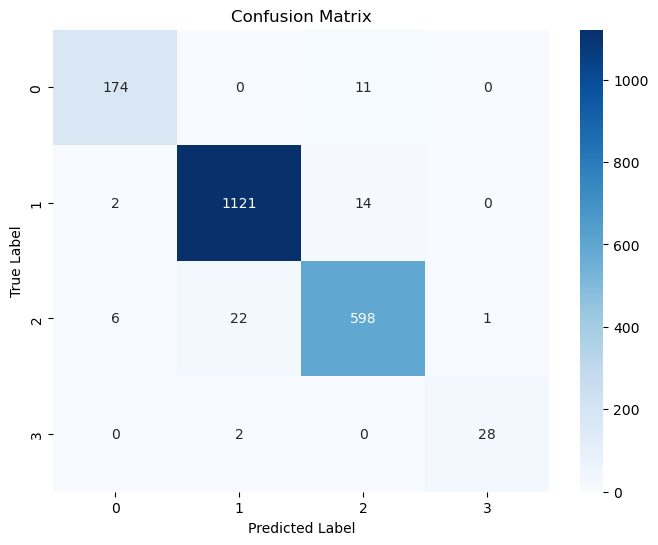

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [10]:
# Define the path to the folder
folder_path = "MODElS"

# Define the full path including the folder and filename
model_path = os.path.join(folder_path, "CNN10.h5")

# Save the model
model.save(model_path)

In [11]:
from tensorflow.keras.models import load_model
model_path = 'MODElS/CNN10.h5'
loaded_model = load_model(model_path)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


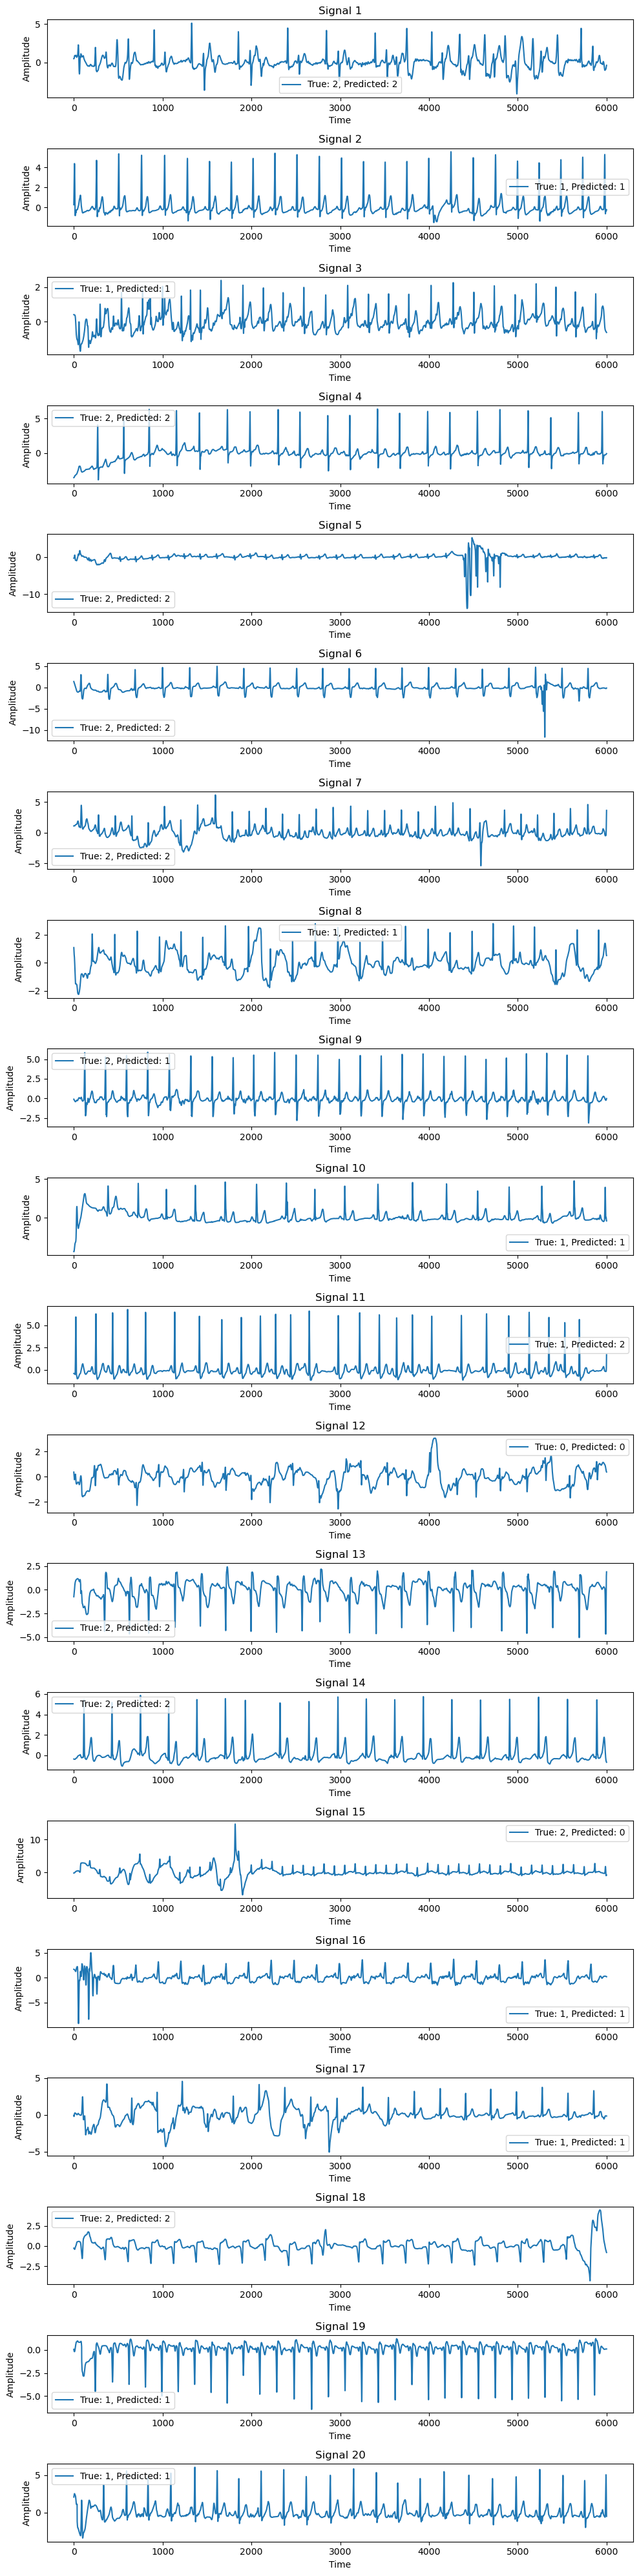

Correct Predictions: 1921
Incorrect Predictions: 58


In [12]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, label_encoder, num_samples=10):
    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct

    # Reverse label mapping
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i].squeeze()  # Squeeze to convert (N, 1) to (N,)
        true_label = reverse_label_mapping[y_test[i]]
        predicted_label = reverse_label_mapping[predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")

plot_and_predict(X_test, y_test, loaded_model, label_encoder, num_samples=20)